In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import os

# 1. Cargar la vista de clustering v2
for p in ['../data/v2/clustering_feature_view.csv', 'clustering/data/v2/clustering_feature_view.csv', 'data/v2/clustering_feature_view.csv']:
    if os.path.exists(p):
        df_full = pd.read_csv(p)
        break
else:
    raise FileNotFoundError('No se encontro el archivo clustering_feature_view.csv')

# 2. Excluir el identificador
df_features = df_full.drop(columns=["patient_id"])

# 3. Separar numéricas de categóricas
num_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_features.select_dtypes(exclude=[np.number]).columns.tolist()

# 4. Pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')), 
        ('onehot', OneHotEncoder(sparse_output=False, drop='first'))
    ]), cat_cols)
])

# 5. Transformar
X_processed = preprocessor.fit_transform(df_features)
print(f"Dataset preprocesado, forma: {X_processed.shape}")


Dataset preprocesado, forma: (2000, 28)


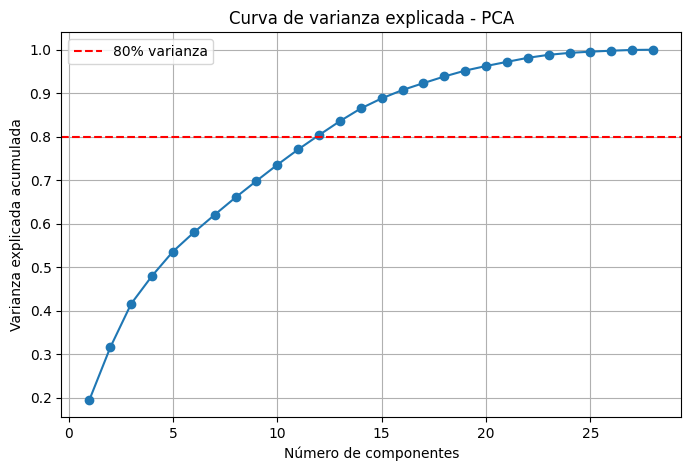

Componentes para 80% de varianza: 12


In [2]:
import matplotlib.pyplot as plt

pca = PCA()
X_pca_full = pca.fit_transform(X_processed)

varianza_explicada_acum = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_explicada_acum) + 1), varianza_explicada_acum, marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Curva de varianza explicada - PCA")
plt.grid(True)
plt.axhline(y=0.80, color="r", linestyle="--", label="80% varianza")
plt.legend()
plt.show()

# Retener hasta 80% varianza o fijo (el usuario usaba 12 componentes, el docente usa 80%)
n_pca_80 = int(np.searchsorted(varianza_explicada_acum, 0.80) + 1)
print(f"Componentes para 80% de varianza: {n_pca_80}")
X_pca = X_pca_full[:, :n_pca_80]


In [3]:
import plotly.graph_objs as go
import plotly.io as pio
import colorsys

# Usar los primeros 5 componentes para gráfica (si existen al menos 5)
if X_pca_full.shape[1] >= 5:
    pc1 = X_pca_full[:, 0]
    pc2 = X_pca_full[:, 1]
    pc3 = X_pca_full[:, 2]
    pc4 = X_pca_full[:, 3]
    pc5 = X_pca_full[:, 4]

    # Normalizar PC4 (tono) y PC5 (brillo)
    norm_pc4 = (pc4 - np.min(pc4)) / (np.max(pc4) - np.min(pc4) + 1e-9)
    norm_pc5 = (pc5 - np.min(pc5)) / (np.max(pc5) - np.min(pc5) + 1e-9)

    rgb_colors = [colorsys.hsv_to_rgb(h, 0.75, v) for h, v in zip(norm_pc4, norm_pc5)]
    def rgb_to_hex(rgb):
        return '#%02x%02x%02x' % tuple(int(255*x) for x in rgb)
    hex_colors = [rgb_to_hex(rgb) for rgb in rgb_colors]

    trace = go.Scatter3d(
        x=pc1, y=pc2, z=pc3,
        mode='markers',
        marker=dict(size=4, color=hex_colors),
        text=[f'PC4: {c4:.2f}<br>PC5: {c5:.2f}' for c4, c5 in zip(pc4, pc5)],
    )

    layout = go.Layout(
        scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
        title='PCA: 5 componentes (x=PC1, y=PC2, z=PC3, color=PC4, brillo=PC5)',
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig = go.Figure(data=[trace], layout=layout)
    fig.show()
else:
    print("No hay suficientes componentes para esta gráfica.")


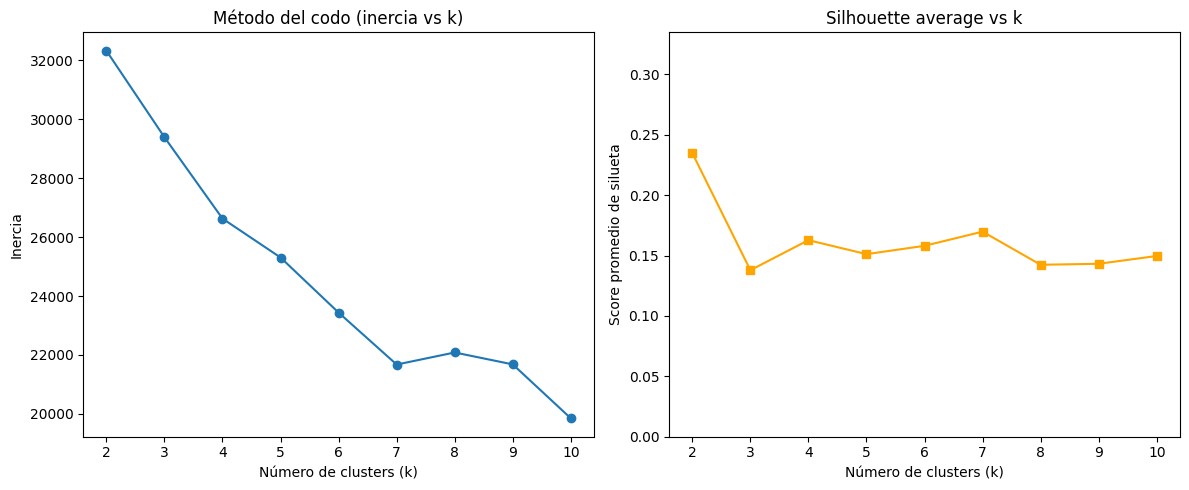

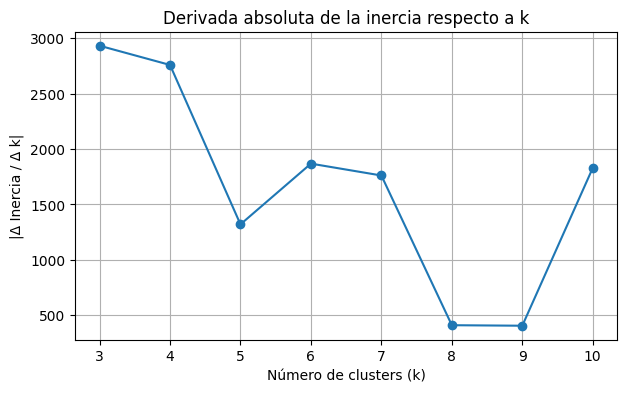

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(k_range, inertias, marker='o')
ax[0].set_title('Método del codo (inercia vs k)')
ax[0].set_xlabel('Número de clusters (k)')
ax[0].set_ylabel('Inercia')

ax[1].plot(k_range, silhouette_scores, marker='s', color='orange')
ax[1].set_title('Silhouette average vs k')
ax[1].set_xlabel('Número de clusters (k)')
ax[1].set_ylabel('Score promedio de silueta')
ax[1].set_ylim(0, max(silhouette_scores) + 0.1)

plt.tight_layout()
plt.show()

inertias = np.array(inertias)
k_array = np.array(list(k_range))
d_inercia = np.abs(np.diff(inertias) / np.diff(k_array))

plt.figure(figsize=(7, 4))
plt.plot(k_array[1:], d_inercia, marker='o')
plt.title('Derivada absoluta de la inercia respecto a k')
plt.xlabel('Número de clusters (k)')
plt.ylabel('|Δ Inercia / Δ k|')
plt.grid(True)
plt.show()


In [5]:
inits = ['k-means++', 'random']
results = {}
K_OPTIMO = 4 # Basado en los análisis del usuario y docente

for init in inits:
    kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=20, init=init)
    labels = kmeans.fit_predict(X_pca)
    inertia = kmeans.inertia_
    sil_score = silhouette_score(X_pca, labels)
    results[init] = {
        'labels': labels,
        'inertia': inertia,
        'silhouette': sil_score,
        'centers': kmeans.cluster_centers_
    }
    print(f"Init: {init:10s} | Inertia: {inertia:.2f} | Silhouette: {sil_score:.4f}")

best_init = max(results, key=lambda x: results[x]['silhouette'])
best_labels = results[best_init]['labels']
best_centers = results[best_init]['centers']
best_sil = results[best_init]['silhouette']

print(f"Mejor inicialización: {best_init}")

import plotly.express as px
fig_3d = px.scatter_3d(
    x=X_pca[:, 0], y=X_pca[:, 1], z=X_pca[:, 2],
    color=best_labels.astype(str),
    labels={"x": "PC1", "y": "PC2", "z": "PC3", "color": "Cluster"},
    opacity=0.55,
    title=f"Clusters KMeans (k={K_OPTIMO}) - Proyección 3D PCA"
)
fig_3d.show()


Init: k-means++  | Inertia: 26625.01 | Silhouette: 0.1627
Init: random     | Inertia: 26624.94 | Silhouette: 0.1626
Mejor inicialización: k-means++


In [6]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from IPython.display import display

MIN_CLUSTER_FRAC = 0.03
search_k_range = range(3, 8)
linkages = ["ward", "average", "complete"]

rows = []
n = len(X_pca)
min_size = int(MIN_CLUSTER_FRAC * n)

for linkage in linkages:
    for k in search_k_range:
        if linkage == "ward":
            model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        else:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage, metric="euclidean")
        labels = model.fit_predict(X_pca)
        counts = np.bincount(labels)
        if counts.min() < min_size:
            continue
        sil = silhouette_score(X_pca, labels)
        ari = adjusted_rand_score(best_labels, labels)
        rows.append({
            "linkage": linkage,
            "n_clusters": k,
            "silhouette": sil,
            "ari_vs_kmeans": ari,
            "min_cluster": int(counts.min())
        })

df_agglo_grid = pd.DataFrame(rows).sort_values(["silhouette", "ari_vs_kmeans"], ascending=False)
if len(df_agglo_grid) > 0:
    best_row = df_agglo_grid.iloc[0]
    print("Mejores configuraciones Jerárquico:")
    display(df_agglo_grid.head())
    
    best_linkage = best_row["linkage"]
    best_k = int(best_row["n_clusters"])
    
    if best_linkage == "ward":
        agglo = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
    else:
        agglo = AgglomerativeClustering(n_clusters=best_k, linkage=best_linkage, metric="euclidean")
        
    agglo_labels = agglo.fit_predict(X_pca)
    fig_agglo_3d = px.scatter_3d(
        x=X_pca[:, 0], y=X_pca[:, 1], z=X_pca[:, 2],
        color=agglo_labels.astype(str),
        labels={"x": "PC1", "y": "PC2", "z": "PC3", "color": "Cluster (Agglo)"},
        opacity=0.45,
        title=f"Agglomerative — linkage={best_linkage}, k={best_k}"
    )
    fig_agglo_3d.show()
else:
    print("Ninguna config pasó el filtro de tamaño mínimo.")


Mejores configuraciones Jerárquico:


,linkage,n_clusters,silhouette,ari_vs_kmeans,min_cluster
0,ward,3,0.175088,0.337811,411
1,ward,4,0.097900,0.425093,411


In [7]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

TARGET_NOISE_FRAC = 0.05
MIN_SAMPLES = 10

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, metric="euclidean")
nn.fit(X_pca)
k_dist = np.sort(nn.kneighbors(X_pca)[0][:, -1])
eps_grid = np.unique(
    np.round(np.percentile(k_dist, [70, 75, 80, 85, 88, 90, 92, 94, 95, 96, 97, 98]), 3)
)

tune_rows = []
for eps in eps_grid:
    labels = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, metric="euclidean").fit_predict(X_pca)
    n_anom = int((labels == -1).sum())
    noise_frac = n_anom / len(labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    tune_rows.append({
        "eps": eps,
        "n_anomalias": n_anom,
        "noise_frac": noise_frac,
        "n_clusters_densos": n_clusters,
        "dist_to_target": abs(noise_frac - TARGET_NOISE_FRAC),
    })

df_dbscan_tune = pd.DataFrame(tune_rows).sort_values("dist_to_target")
display(df_dbscan_tune.head())

best_eps = float(df_dbscan_tune.iloc[0]["eps"])
print(f"Mejor EPS para anomalías (~{TARGET_NOISE_FRAC:.0%} ruido): {best_eps}")

dbscan_anom_labels = DBSCAN(eps=best_eps, min_samples=MIN_SAMPLES, metric="euclidean").fit_predict(X_pca)
is_anomaly = dbscan_anom_labels == -1

point_class = np.where(is_anomaly, "anomalía", "normal")
fig_anom_3d = px.scatter_3d(
    x=X_pca[:, 0], y=X_pca[:, 1], z=X_pca[:, 2], color=point_class,
    labels={"x": "PC1", "y": "PC2", "z": "PC3", "color": "Clase"},
    opacity=0.5, color_discrete_map={"normal": "#636efa", "anomalía": "#ef553b"},
    title=f"DBSCAN anomalías — eps={best_eps} | {is_anomaly.sum():,} puntos ({is_anomaly.mean():.2%})",
)
fig_anom_3d.show()


,eps,n_anomalias,noise_frac,n_clusters_densos,dist_to_target
5,3.874,92,0.0460,2,0.0040
6,4.121,67,0.0335,2,0.0165
4,3.649,135,0.0675,1,0.0175
7,4.320,53,0.0265,2,0.0235
8,4.515,38,0.0190,2,0.0310


Mejor EPS para anomalías (~5% ruido): 3.874


In [8]:
eps_values = np.arange(1.0, 6.0, 0.5)
dbscan_results = []

for eps in eps_values:
    dbscan_tmp = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, metric='euclidean')
    labels_tmp = dbscan_tmp.fit_predict(X_pca)
    n_clusters = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    n_noise = np.sum(labels_tmp == -1)
    if n_clusters > 1 and n_clusters < len(X_pca):
        silhouette = silhouette_score(X_pca, labels_tmp, metric='euclidean')
    else:
        silhouette = np.nan
    dbscan_results.append({'eps': eps, 'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': silhouette})

dbscan_results_df = pd.DataFrame(dbscan_results)
print("Barrido EPS:")
display(dbscan_results_df)

valid = dbscan_results_df.dropna(subset=['silhouette'])
if len(valid) > 0:
    best_dbscan_idx = valid["silhouette"].idxmax()
    best_eps_clust = dbscan_results_df.loc[best_dbscan_idx, "eps"]
    print(f"Mejor EPS según silhouette para clustering: {best_eps_clust}")
    
    dbscan_final = DBSCAN(eps=best_eps_clust, min_samples=MIN_SAMPLES, metric='euclidean')
    labels_final = dbscan_final.fit_predict(X_pca)
    
    fig_dbscan = px.scatter_3d(
        x=X_pca[:, 0], y=X_pca[:, 1], z=X_pca[:, 2],
        color=labels_final.astype(str),
        title=f"DBSCAN Clusters Óptimos eps={best_eps_clust}"
    )
    fig_dbscan.show()
else:
    print("No se encontró un EPS con múltiples clusters y silhouette válido.")


Barrido EPS:


,eps,n_clusters,n_noise,silhouette
0,1.0,5,1304,-0.040823
1,1.5,8,905,-0.070990
2,2.0,8,618,-0.003907
3,2.5,6,417,0.063560
4,3.0,4,256,0.103124
5,3.5,1,155,NaN
6,4.0,2,79,0.329904
7,4.5,2,38,0.355484
8,5.0,3,15,0.366465
9,5.5,3,7,0.374498


Mejor EPS según silhouette para clustering: 5.5
